# Inferential Analysis of Audience Reaction and Content Popularity

This notebook extends the completed descriptive analysis into formal inferential testing using the lecture framework from statistical inference, hypothesis testing, ANOVA, and multiple linear regression.

The main regression specification is:

`log_box_office ~ audienceScore + initial_combined_sentiment_score + log_initial_review_count + initial_sentiment_x_log_review_count`

The goal is to test whether stronger audience reaction and stronger early sentiment signals are associated with higher movie popularity, using `log_box_office` as the response variable.

## 1. Research Question, Hypotheses, and Lecture-Aligned Method

**Research question:** Do positive audience reactions improve content popularity?

Following the lecture notes, the core model in this notebook is **multiple linear regression estimated by Ordinary Least Squares (OLS)**.

**Model-level null hypothesis (H0):**
There is no significant linear relationship between the response variable `log_box_office` and the explanatory variables `audienceScore`, `initial_combined_sentiment_score`, `log_initial_review_count`, and `initial_sentiment_x_log_review_count`.

**Model-level alternative hypothesis (H1):**
At least one regression coefficient differs from zero, meaning the explanatory variables jointly provide significant evidence of a linear relationship with `log_box_office`.

**Coefficient-level hypotheses:**
- For each predictor, `H0: beta_i = 0` versus `H1: beta_i != 0`
- For the interaction term, `H0: beta_interaction = 0` versus `H1: beta_interaction != 0`

**Level of significance:** `alpha = 0.05`

**Lecture-aligned core outputs:** correlation-based relationship checks, hypothesis testing using p-values, ANOVA / overall F-test for the regression model, coefficient significance tests, and the five standard linear-regression assumptions.

## 2. Setup and Load Final Dataset

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings(
    'ignore',
    message='.*vert: bool will be deprecated in a future version.*',
    category=PendingDeprecationWarning,
)

ALPHA = 0.05
OUTCOME = 'log_box_office'
PREDICTORS = [
    'audienceScore',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
    'initial_sentiment_x_log_review_count',
]
MODEL_COLUMNS = [OUTCOME, *PREDICTORS]
FORMULA = 'log_box_office ~ audienceScore + initial_combined_sentiment_score + log_initial_review_count + initial_sentiment_x_log_review_count'


def resolve_data_path() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for base in candidates:
        candidate = base / 'data' / 'final' / 'final.csv'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find data/final/final.csv from the current working directory.')


DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)

print(f'Data path: {DATA_PATH}')
print(f'Raw dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')

Data path: c:\Users\dinuka\Documents\movie sentiment\data\final\final.csv
Raw dataset shape: 4,072 rows x 29 columns


## 3. Validate Inferential Columns and Build the Analysis Frame

This section bridges the descriptive notebook and the inferential notebook by confirming that the final model variables exist, are numeric, and are complete enough for formal inference.

In [2]:
required_columns = [
    'boxOffice',
    'box_office_num',
    'log_box_office',
    'initial_combined_sentiment_label',
    *PREDICTORS,
]

missing_required = [column for column in required_columns if column not in df.columns]
if missing_required:
    raise KeyError(f'Missing required columns: {missing_required}')

analysis_df = df.copy()
for column in ['box_office_num', 'log_box_office', *PREDICTORS]:
    analysis_df[column] = pd.to_numeric(analysis_df[column], errors='coerce')

validation_summary = pd.DataFrame({
    'non_null_count': analysis_df[required_columns].notna().sum(),
    'missing_count': analysis_df[required_columns].isna().sum(),
    'missing_pct': analysis_df[required_columns].isna().mean() * 100,
})

inferential_df = analysis_df[np.isfinite(analysis_df[OUTCOME])].copy()
inferential_df = inferential_df.dropna(subset=MODEL_COLUMNS)

print(f'Rows with finite {OUTCOME}: {np.isfinite(analysis_df[OUTCOME]).sum():,}')
print(f'Rows retained for full inferential model: {inferential_df.shape[0]:,}')

display(validation_summary)
display(inferential_df[MODEL_COLUMNS].describe().T)

Rows with finite log_box_office: 3,748
Rows retained for full inferential model: 3,747


,non_null_count,missing_count,missing_pct
boxOffice,3749,323,7.9322
box_office_num,3749,323,7.9322
log_box_office,3748,324,7.9568
initial_combined_sentiment_label,4072,0,0.0000
audienceScore,4060,12,0.2947
initial_combined_sentiment_score,4072,0,0.0000
log_initial_review_count,4072,0,0.0000
initial_sentiment_x_log_review_count,4072,0,0.0000


,count,mean,std,min,25%,50%,75%,max
log_box_office,"3,747.0000",7.0874,0.9562,0.3010,6.5798,7.3324,7.7612,8.9337
audienceScore,"3,747.0000",61.5540,19.0244,10.0000,47.0000,62.0000,77.0000,99.0000
initial_combined_sentiment_score,"3,747.0000",0.0904,0.5685,-1.0000,-0.4038,0.1222,0.5934,1.0000
log_initial_review_count,"3,747.0000",3.9115,0.4741,3.0910,3.5264,3.9120,4.2767,5.2627
initial_sentiment_x_log_review_count,"3,747.0000",0.3443,2.2046,-4.1744,-1.5697,0.4758,2.3100,4.8481


In [3]:
box_office_validation = inferential_df[['boxOffice', 'box_office_num', 'log_box_office']].copy()
box_office_validation['recomputed_log_box_office'] = np.log10(box_office_validation['box_office_num'])
box_office_validation['abs_diff'] = (
    box_office_validation['log_box_office'] - box_office_validation['recomputed_log_box_office']
).abs()

print('Quick validation of stored logged box office:')
print(box_office_validation['abs_diff'].describe())
print(f"Maximum absolute difference: {box_office_validation['abs_diff'].max():.10f}")

Quick validation of stored logged box office:
count   3,747.0000
mean        0.0000
std         0.0000
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         0.0000
Name: abs_diff, dtype: float64
Maximum absolute difference: 0.0000000000


## 4. Relationship Checks Before Regression

The lecture notes introduce correlation as a measure of the relationship between numerical variables. This section reports Pearson correlation for direct alignment with that material, while Spearman correlation is included as a supporting nonparametric check.

,predictor,n,pearson_r,pearson_p,spearman_rho,spearman_p
2,log_initial_review_count,3747,0.6267,0.0000,0.6477,0.0000
1,initial_combined_sentiment_score,3747,-0.1387,0.0000,-0.0903,0.0000
3,initial_sentiment_x_log_review_count,3747,-0.0994,0.0000,-0.0458,0.0051
0,audienceScore,3747,0.0841,0.0000,0.1128,0.0000


Interpretation note: Pearson correlation measures the strength and direction of the linear relationship between each explanatory variable and the response variable. A small p-value indicates evidence of a statistically significant linear association.


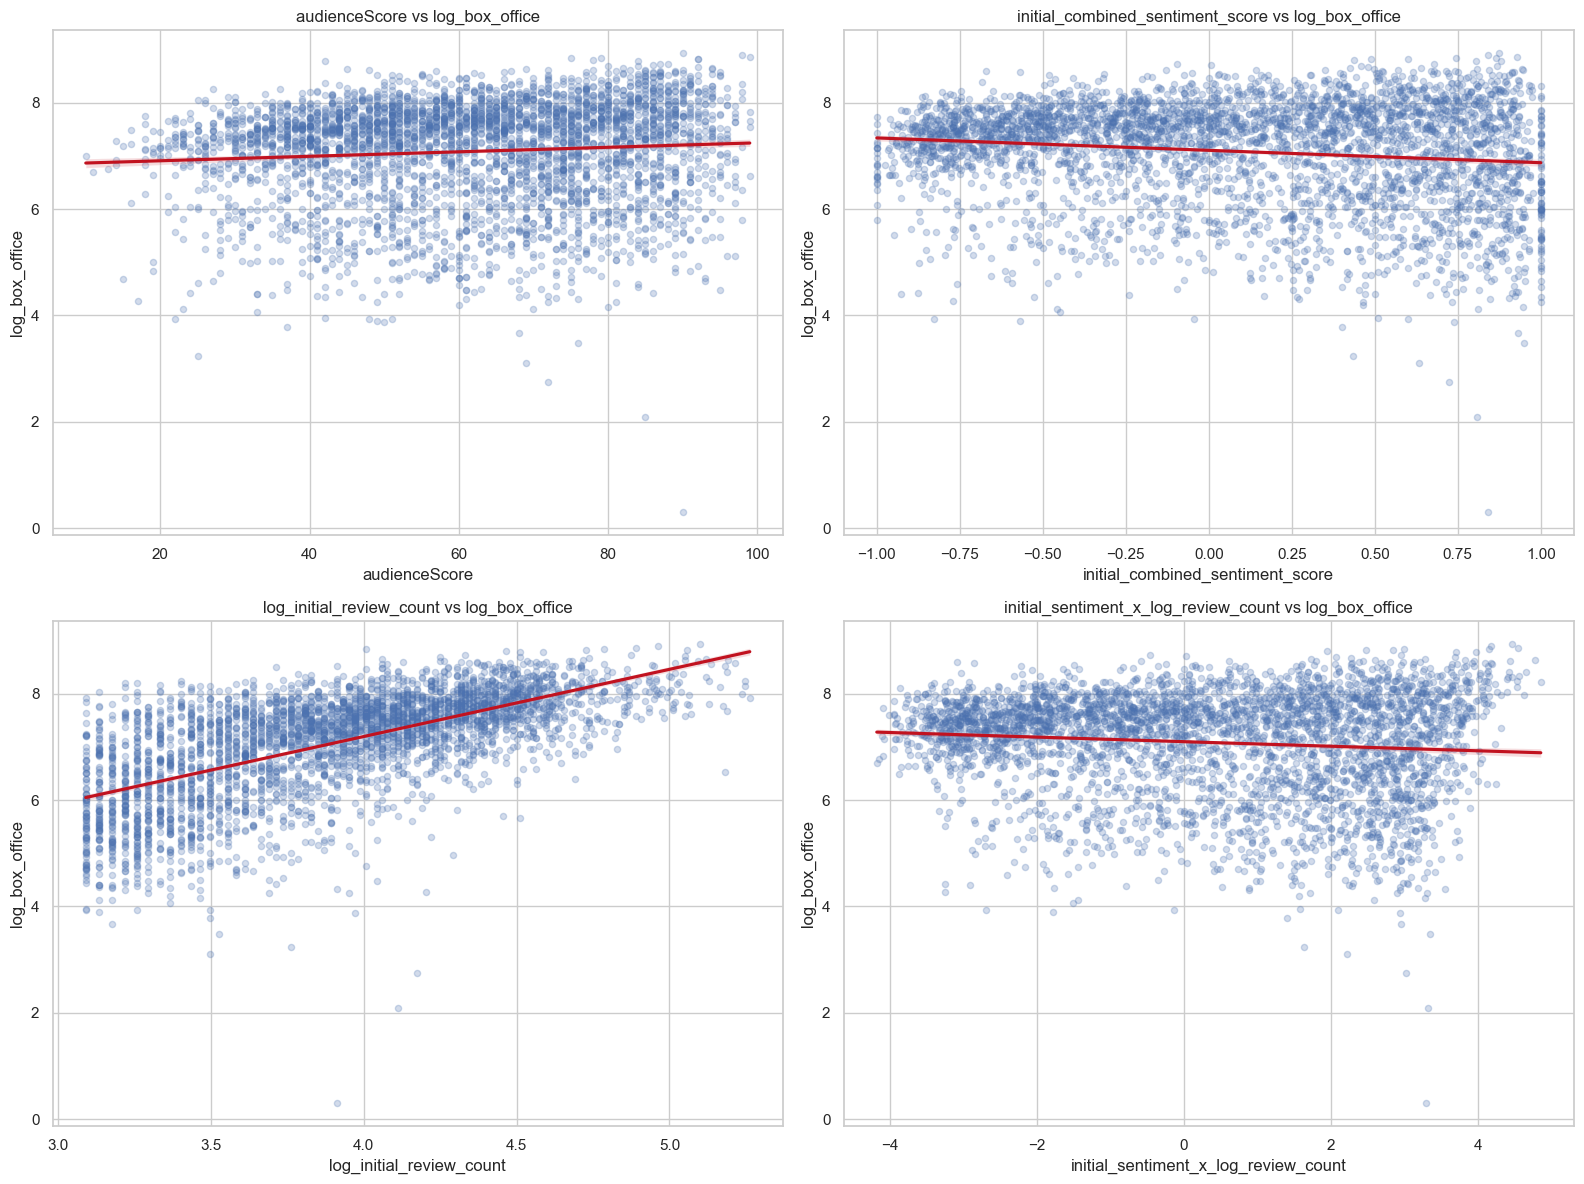

In [4]:
correlation_results = []
for predictor in PREDICTORS:
    pair_df = inferential_df[[predictor, OUTCOME]].dropna()
    pearson_r, pearson_p = stats.pearsonr(pair_df[predictor], pair_df[OUTCOME])
    spearman_rho, spearman_p = stats.spearmanr(pair_df[predictor], pair_df[OUTCOME])
    correlation_results.append({
        'predictor': predictor,
        'n': len(pair_df),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_rho': spearman_rho,
        'spearman_p': spearman_p,
    })

correlation_results = pd.DataFrame(correlation_results).sort_values('pearson_p')
display(correlation_results)
print('Interpretation note: Pearson correlation measures the strength and direction of the linear relationship between each explanatory variable and the response variable. A small p-value indicates evidence of a statistically significant linear association.')

plot_df = inferential_df[[OUTCOME, *PREDICTORS]].dropna()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, predictor in zip(axes.flat, PREDICTORS):
    sns.regplot(
        data=plot_df,
        x=predictor,
        y=OUTCOME,
        scatter_kws={'alpha': 0.25, 's': 20},
        line_kws={'color': '#c1121f'},
        ax=ax,
    )
    ax.set_title(f'{predictor} vs {OUTCOME}')

plt.tight_layout()
plt.show()

## 5. Group Comparison Tests

These tests compare the mean or distribution of `log_box_office` across groups to complement the continuous-variable analysis. The ANOVA-style comparison is aligned with the lecture treatment of hypothesis testing for mean differences across more than two groups.

,count,mean,median,std
initial_combined_sentiment_label,,,,
negative,1291,7.2142,7.3979,0.7510
mixed,707,7.1975,7.4200,0.8662
positive,1749,6.9494,7.1732,1.0973


,test,statistic,p_value
0,One-way ANOVA,34.8873,0.0000
1,Kruskal-Wallis,30.9764,0.0000


Interpretation note: In ANOVA-style hypothesis testing, a small p-value indicates that at least one group mean differs from the others. Kruskal-Wallis provides a nonparametric check for the same grouping question.


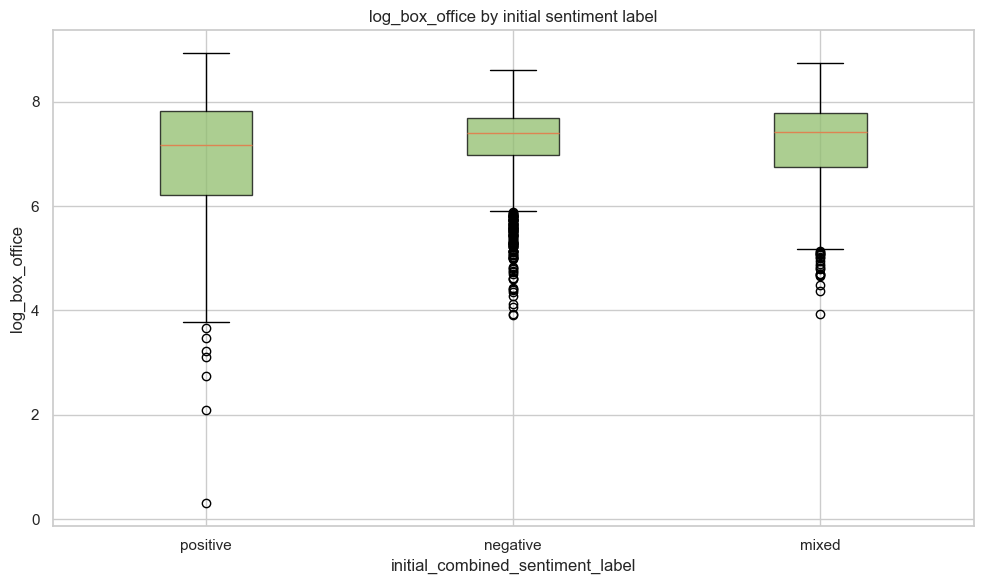

In [5]:
sentiment_group_summary = inferential_df.groupby('initial_combined_sentiment_label')[OUTCOME].agg(
    count='size',
    mean='mean',
    median='median',
    std='std',
).sort_values('mean', ascending=False)
display(sentiment_group_summary)

anova_groups = [
    group[OUTCOME].to_numpy()
    for _, group in inferential_df.groupby('initial_combined_sentiment_label')
]
anova_stat, anova_p = stats.f_oneway(*anova_groups)
kruskal_stat, kruskal_p = stats.kruskal(*anova_groups)

group_test_results = pd.DataFrame([
    {'test': 'One-way ANOVA', 'statistic': anova_stat, 'p_value': anova_p},
    {'test': 'Kruskal-Wallis', 'statistic': kruskal_stat, 'p_value': kruskal_p},
])
display(group_test_results)
print('Interpretation note: In ANOVA-style hypothesis testing, a small p-value indicates that at least one group mean differs from the others. Kruskal-Wallis provides a nonparametric check for the same grouping question.')

boxplot_order = inferential_df['initial_combined_sentiment_label'].value_counts().index.tolist()
boxplot_groups = [
    inferential_df.loc[inferential_df['initial_combined_sentiment_label'] == label, OUTCOME].dropna().to_numpy()
    for label in boxplot_order
]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(boxplot_groups, patch_artist=True, tick_labels=boxplot_order)
for patch in bp['boxes']:
    patch.set_facecolor('#90be6d')
    patch.set_alpha(0.75)
ax.set_title(f'{OUTCOME} by initial sentiment label')
ax.set_xlabel('initial_combined_sentiment_label')
ax.set_ylabel(OUTCOME)
plt.tight_layout()
plt.show()

In [6]:
audience_median = inferential_df['audienceScore'].median()
inferential_df['audience_score_group'] = np.where(
    inferential_df['audienceScore'] >= audience_median,
    'High audience score',
    'Low audience score',
)

audience_group_summary = inferential_df.groupby('audience_score_group')[OUTCOME].agg(
    count='size',
    mean='mean',
    median='median',
    std='std',
)
display(audience_group_summary)

high_group = inferential_df.loc[inferential_df['audience_score_group'] == 'High audience score', OUTCOME]
low_group = inferential_df.loc[inferential_df['audience_score_group'] == 'Low audience score', OUTCOME]
welch_stat, welch_p = stats.ttest_ind(high_group, low_group, equal_var=False)
mw_stat, mw_p = stats.mannwhitneyu(high_group, low_group, alternative='two-sided')

audience_group_tests = pd.DataFrame([
    {'test': 'Welch t-test', 'statistic': welch_stat, 'p_value': welch_p},
    {'test': 'Mann-Whitney U', 'statistic': mw_stat, 'p_value': mw_p},
])
display(audience_group_tests)
print('Interpretation note: The two-group tests compare the central tendency of log_box_office between movies with relatively high and low audience scores. These are supporting results only and do not replace the full regression model.')

,count,mean,median,std
audience_score_group,,,,
High audience score,1933,7.1430,7.3874,0.9828
Low audience score,1814,7.0283,7.2978,0.9235


,test,statistic,p_value
0,Welch t-test,3.6838,0.0002
1,Mann-Whitney U,"1,915,164.5000",0.0000


Interpretation note: The two-group tests compare the central tendency of log_box_office between movies with relatively high and low audience scores. These are supporting results only and do not replace the full regression model.


## 6. Multiple Linear Regression Estimated by OLS

This is the main lecture-aligned hypothesis test. The model is a **multiple linear regression** and OLS is the estimation method used to fit it.

The overall model is assessed with the **F-test / ANOVA view**, and each coefficient is assessed with its own significance test.

Interpretation structure:
- The overall F-test evaluates whether the regression model is statistically significant as a whole.
- The coefficient tests evaluate whether each explanatory variable contributes significantly after controlling for the others.
- `R^2` and adjusted `R^2` summarize explanatory power.

In [7]:
model_df = inferential_df[MODEL_COLUMNS].dropna().copy()
X = sm.add_constant(model_df[PREDICTORS])
y = model_df[OUTCOME]

ols_model = sm.OLS(y, X).fit(cov_type='HC3')
ols_model_classical = smf.ols(FORMULA, data=model_df).fit()
anova_table = sm.stats.anova_lm(ols_model_classical, typ=1)

display(ols_model.summary2())
display(anova_table)

coefficient_table = pd.DataFrame({
    'term': ols_model.params.index,
    'coef': ols_model.params.values,
    'std_err_hc3': ols_model.bse.values,
    'z_or_t': ols_model.tvalues.values,
    'p_value': ols_model.pvalues.values,
    'ci_lower': ols_model.conf_int()[0].values,
    'ci_upper': ols_model.conf_int()[1].values,
})
display(coefficient_table)

model_fit_summary = pd.DataFrame([
    {
        'n_obs': int(ols_model.nobs),
        'r_squared': ols_model.rsquared,
        'adj_r_squared': ols_model.rsquared_adj,
        'f_statistic': float(ols_model.fvalue),
        'model_p_value': float(ols_model.f_pvalue),
    }
])
display(model_fit_summary)
print('Interpretation note: The ANOVA / F-test evaluates whether the regression model is useful overall. The coefficient tests evaluate whether individual explanatory variables have significant partial effects after controlling for the others.')

<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Results: Ordinary least squares
====================================================================================
Model:                    OLS                    Adj. R-squared:           0.438    
Dependent Variable:       log_box_office         AIC:                      8146.0226
Date:                     2026-04-23 15:59       BIC:                      8177.1662
No. Observations:         3747                   Log-Likelihood:           -4068.0  
Df Model:                 4                      F-statistic:              681.4    
Df Residuals:             3742                   Prob (F-statistic):       0.00     
R-squared:                0.438                  Scale:                    0.51417  
------------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------------------
const                                 1.9628   0.1195 16.4296 0.0000  1.7287  2.1970
audienceScore                         0.0103   0.0008 12.2543 0.0000  0.0087  0.0120
initial_combined_sentiment_score     -1.5620   0.1814 -8.6132 0.0000 -1.9175 -1.2066
log_initial_review_count              1.1579   0.0267 43.3857 0.0000  1.1056  1.2102
initial_sentiment_x_log_review_count  0.2954   0.0450  6.5570 0.0000  0.2071  0.3836
------------------------------------------------------------------------------------
Omnibus:                    720.857            Durbin-Watson:               1.919   
Prob(Omnibus):              0.000              Jarque-Bera (JB):            2888.670
Skew:                       -0.900             Prob(JB):                    0.000   
Kurtosis:                   6.907              Condition No.:               1026    
====================================================================================
Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 1.03e+03. This might indicate                that
there are strong multicollinearity or other numerical                problems.
"""

,df,sum_sq,mean_sq,F,PR(>F)
audienceScore,1.0000,24.2395,24.2395,47.1428,0.0000
initial_combined_sentiment_score,1.0000,225.2291,225.2291,438.0429,0.0000
log_initial_review_count,1.0000,"1,229.2107","1,229.2107","2,390.6635",0.0000
initial_sentiment_x_log_review_count,1.0000,21.9874,21.9874,42.7628,0.0000
Residual,"3,742.0000","1,924.0293",0.5142,NaN,NaN


,term,coef,std_err_hc3,z_or_t,p_value,ci_lower,ci_upper
0,const,1.9628,0.1195,16.4296,0.0000,1.7287,2.1970
1,audienceScore,0.0103,0.0008,12.2543,0.0000,0.0087,0.0120
2,initial_combined_sentiment_score,-1.5620,0.1814,-8.6132,0.0000,-1.9175,-1.2066
3,log_initial_review_count,1.1579,0.0267,43.3857,0.0000,1.1056,1.2102
4,initial_sentiment_x_log_review_count,0.2954,0.0450,6.5570,0.0000,0.2071,0.3836


,n_obs,r_squared,adj_r_squared,f_statistic,model_p_value
0,3747,0.4382,0.4376,681.3789,0.0000


Interpretation note: The ANOVA / F-test evaluates whether the regression model is useful overall. The coefficient tests evaluate whether individual explanatory variables have significant partial effects after controlling for the others.


## 7. Assumption Checks and Robustness Notes

These checks are organized to match the lecture notes: **linearity, multicollinearity, homoscedasticity, independence, and normality**. The main reported model remains the project formula, and the diagnostics show whether those assumptions are reasonably met or violated.

In report terms, these diagnostics help determine whether the p-values, confidence intervals, and coefficient interpretations from the regression model can be trusted without qualification.

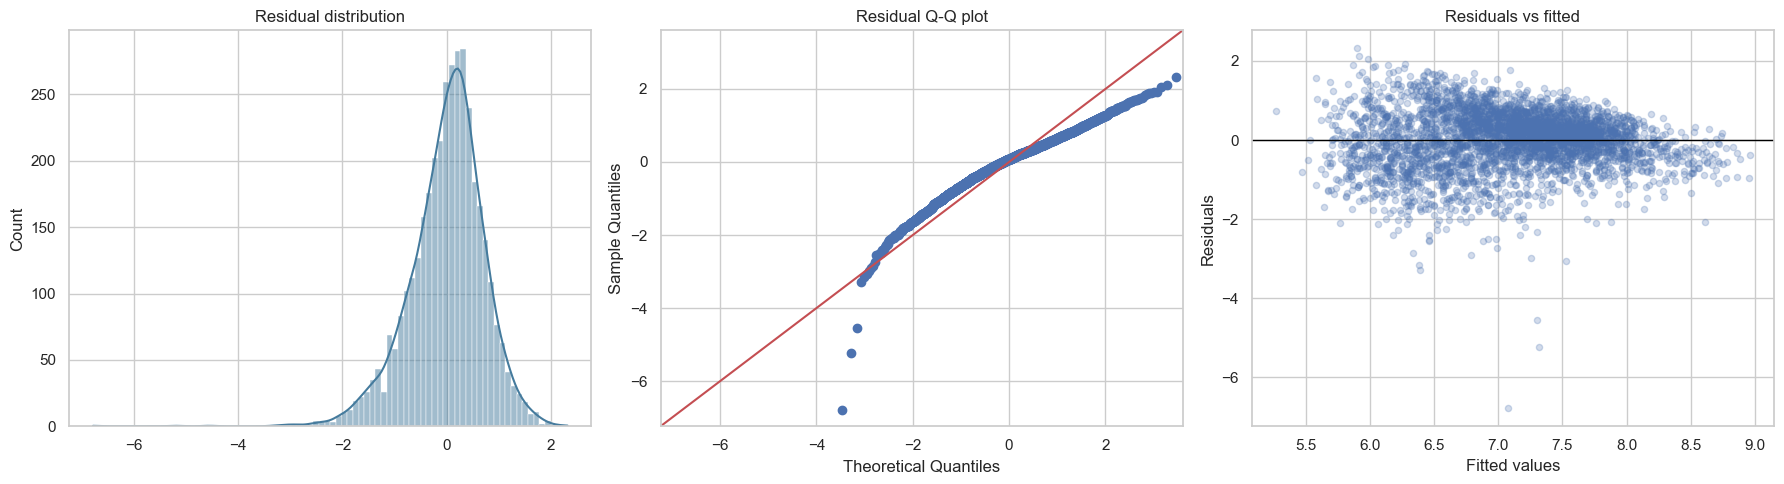

In [8]:
residuals = ols_model.resid
fitted_values = ols_model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(residuals, kde=True, ax=axes[0], color='#457b9d')
axes[0].set_title('Residual distribution')

sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('Residual Q-Q plot')

axes[2].scatter(fitted_values, residuals, alpha=0.25, s=20)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Residuals vs fitted')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [9]:
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, ols_model.model.exog)
dw_stat = durbin_watson(residuals)
diagnostic_tests = pd.DataFrame([
    {'test': 'Breusch-Pagan LM', 'statistic': bp_lm, 'p_value': bp_lm_p},
    {'test': 'Breusch-Pagan F', 'statistic': bp_f, 'p_value': bp_f_p},
    {'test': 'Durbin-Watson', 'statistic': dw_stat, 'p_value': np.nan},
])

vif_table = pd.DataFrame({
    'term': X.columns,
    'vif': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})

assumption_summary = pd.DataFrame([
    {
        'assumption': 'Linearity',
        'how_checked': 'Scatterplots with fitted lines and residuals vs fitted plot',
        'status': 'Reasonably checked visually',
        'note': 'No strong evidence of a purely non-linear pattern, but this remains a visual assessment.'
    },
    {
        'assumption': 'Multicollinearity',
        'how_checked': 'VIF',
        'status': 'Violated in raw interaction model',
        'note': 'The sentiment term and its interaction have very high VIF values; centered robustness check is included.'
    },
    {
        'assumption': 'Homoscedasticity',
        'how_checked': 'Breusch-Pagan test and residuals vs fitted plot',
        'status': 'Violated',
        'note': 'Because heteroskedasticity is present, HC3 robust standard errors are reported.'
    },
    {
        'assumption': 'Independence',
        'how_checked': 'Study design review and Durbin-Watson statistic',
        'status': 'Mostly assumed from cross-sectional movie-level design',
        'note': 'Durbin-Watson is reported, but true independence is primarily a design assumption here.'
    },
    {
        'assumption': 'Normality',
        'how_checked': 'Residual histogram and Q-Q plot',
        'status': 'Not perfectly satisfied',
        'note': 'Residuals deviate from normality, though the sample size is large.'
    },
])

display(diagnostic_tests)
display(vif_table)
display(assumption_summary)
print('Interpretation note: Assumption violations do not automatically invalidate the analysis, but they do change how confidently the regression results should be interpreted. In this notebook, heteroskedasticity is handled with HC3 robust standard errors, while multicollinearity is documented and checked with a centered interaction robustness analysis.')

,test,statistic,p_value
0,Breusch-Pagan LM,135.2182,0.0000
1,Breusch-Pagan F,35.0233,0.0000
2,Durbin-Watson,1.9188,NaN


,term,vif
0,const,90.5591
1,audienceScore,1.7831
2,initial_combined_sentiment_score,72.1515
3,log_initial_review_count,1.1522
4,initial_sentiment_x_log_review_count,72.2320


,assumption,how_checked,status,note
0,Linearity,Scatterplots with fitted lines and residuals v...,Reasonably checked visually,No strong evidence of a purely non-linear patt...
1,Multicollinearity,VIF,Violated in raw interaction model,The sentiment term and its interaction have ve...
2,Homoscedasticity,Breusch-Pagan test and residuals vs fitted plot,Violated,"Because heteroskedasticity is present, HC3 rob..."
3,Independence,Study design review and Durbin-Watson statistic,Mostly assumed from cross-sectional movie-leve...,"Durbin-Watson is reported, but true independen..."
4,Normality,Residual histogram and Q-Q plot,Not perfectly satisfied,"Residuals deviate from normality, though the s..."


Interpretation note: Assumption violations do not automatically invalidate the analysis, but they do change how confidently the regression results should be interpreted. In this notebook, heteroskedasticity is handled with HC3 robust standard errors, while multicollinearity is documented and checked with a centered interaction robustness analysis.


In [10]:
robustness_df = inferential_df[['audienceScore', 'initial_combined_sentiment_score', 'log_initial_review_count', OUTCOME]].dropna().copy()
robustness_df['sentiment_c'] = robustness_df['initial_combined_sentiment_score'] - robustness_df['initial_combined_sentiment_score'].mean()
robustness_df['review_count_c'] = robustness_df['log_initial_review_count'] - robustness_df['log_initial_review_count'].mean()
robustness_df['interaction_c'] = robustness_df['sentiment_c'] * robustness_df['review_count_c']

X_centered = sm.add_constant(robustness_df[['audienceScore', 'sentiment_c', 'review_count_c', 'interaction_c']])
centered_model = sm.OLS(robustness_df[OUTCOME], X_centered).fit(cov_type='HC3')

centered_vif_table = pd.DataFrame({
    'term': X_centered.columns,
    'vif': [variance_inflation_factor(X_centered.values, i) for i in range(X_centered.shape[1])],
})

display(centered_vif_table)
display(pd.DataFrame({
    'term': centered_model.params.index,
    'coef': centered_model.params.values,
    'p_value': centered_model.pvalues.values,
}))

,term,vif
0,const,19.6922
1,audienceScore,1.7831
2,sentiment_c,1.8037
3,review_count_c,1.0572
4,interaction_c,1.0671


,term,coef,p_value
0,const,6.4550,0.0000
1,audienceScore,0.0103,0.0000
2,sentiment_c,-0.4068,0.0000
3,review_count_c,1.1846,0.0000
4,interaction_c,0.2954,0.0000


## 8. Final Hypothesis Decision and Lecture-Aligned Interpretation

This final section states the statistical decision using the standard hypothesis-testing structure from the lectures: compare the p-value with the significance level, make a reject/fail-to-reject decision, and then interpret the result in the context of the research question.

In [11]:
model_significant = ols_model.f_pvalue < ALPHA
coefficient_signals = coefficient_table.copy()
coefficient_signals['significant_at_0_05'] = coefficient_signals['p_value'] < ALPHA

print('Model-level decision from the overall F-test')
print(f'Significance level (alpha): {ALPHA}')
if model_significant:
    print('Decision: Reject H0.')
    print('Conclusion: The full set of predictors jointly explains a statistically significant share of variation in log_box_office.')
else:
    print('Decision: Fail to reject H0.')
    print('Conclusion: The full set of predictors does not jointly explain log_box_office at the chosen significance level.')

print('\nCoefficient-level evidence from the multiple linear regression')
display(coefficient_signals)

print('Lecture-aligned interpretation guide:')
print('- This analysis is a multiple linear regression model estimated by OLS.')
print('- The overall F-test answers whether the predictors jointly explain the response variable.')
print('- The individual coefficient tests answer which predictors contribute significantly after controlling for the others.')
print('- The final conclusion must be read together with the regression assumptions, especially heteroskedasticity and multicollinearity.')
print('- Because the interaction term is significant, the effect of early sentiment depends on review volume.')
print('- Therefore, the research question should be answered using the full model, not a single coefficient in isolation.')

Model-level decision from the overall F-test
Significance level (alpha): 0.05
Decision: Reject H0.
Conclusion: The full set of predictors jointly explains a statistically significant share of variation in log_box_office.

Coefficient-level evidence from the multiple linear regression


,term,coef,std_err_hc3,z_or_t,p_value,ci_lower,ci_upper,significant_at_0_05
0,const,1.9628,0.1195,16.4296,0.0000,1.7287,2.1970,True
1,audienceScore,0.0103,0.0008,12.2543,0.0000,0.0087,0.0120,True
2,initial_combined_sentiment_score,-1.5620,0.1814,-8.6132,0.0000,-1.9175,-1.2066,True
3,log_initial_review_count,1.1579,0.0267,43.3857,0.0000,1.1056,1.2102,True
4,initial_sentiment_x_log_review_count,0.2954,0.0450,6.5570,0.0000,0.2071,0.3836,True


Lecture-aligned interpretation guide:
- This analysis is a multiple linear regression model estimated by OLS.
- The overall F-test answers whether the predictors jointly explain the response variable.
- The individual coefficient tests answer which predictors contribute significantly after controlling for the others.
- The final conclusion must be read together with the regression assumptions, especially heteroskedasticity and multicollinearity.
- Because the interaction term is significant, the effect of early sentiment depends on review volume.
- Therefore, the research question should be answered using the full model, not a single coefficient in isolation.
